## Post-processing Interferograms from ALOS-2

```bash
cd ~/data/2023TurkeyEQ/ALOS2_A184_20220905_20230220
screen -S ALOS2_A184 -L
load_insar
alos2App.py alos2App.xml --steps --end=ion_unwrap
```

In [41]:
%matplotlib inline
import os
import numpy as np
import platform
from PIL import Image, ImageDraw
from matplotlib import pyplot as plt, ticker
from mintpy.utils import ptime, readfile, writefile, plot as pp, utils as ut, isce_utils
from mintpy.cli import view, subset, prep_isce, mask, geocode
from skimage.transform import resize
from mintpy.view import prep_slice, plot_slice
plt.rcParams.update({'font.size': 12})
cmy = pp.ColormapExt('cmy').colormap

dname = 'ALOS2_A152';  
proj_dir = f'/penguin/hucy/Mandalay/'
work_dir = f'/penguin/hucy/Mandalay/'

# input/output files
gmt_lonlat_file = f'/penguin/eedy/25EQ_myanmar/simple_rupture_trace.lonlat'
date1 = 250211
date2 = 250408
fbase = f'{date1}-{date2}_5rlks_28alks'

int_file = f'filt_{fbase}.int'
cor_file = f'filt_{fbase}.cor'
unw_file = f'filt_{fbase}.unw'
lat_file = f'{fbase}.lat'
lon_file = f'{fbase}.lon'
wbd_file = f'{fbase}.wbd'
msk_file = f'{fbase}.msk'

dem_file = f'/penguin/eedy/25EQ_myanmar/DEM/elevation_mli.dem'
flt_file = f'/penguin/eedy/25EQ_myanmar/simple_rupture_trace.lonlat'

In [42]:
def generate_mask4earthquake_rupture(gmt_lonlat_file, int_file, msk_file, lookup_file, rupture_width=20):
    """Generate mask for earthquake ruptures, to facilitae the phase unwrapping of co-seismic deformation.

    Parameters: rupture_files - list(str), path to the text file of rupture traces in GMT lonlat format
                int_file      - str, path to the interferogram
                msk_file      - str, path to the output mask file
                lookup_file   - list(str), path to the lookup table files, e.g.:
                                'geometryRadar.h5', or 
                                ['lat.rdr', 'lon.rdr']
                rupture_width - int, surface rupture width in pixels
    Returns:    msk_file      - str, path to the output mask file
    """
    work_dir = os.path.dirname(os.path.abspath(int_file))
    # go to work directory
    os.chdir(work_dir)
    print('Go to directory:', work_dir)

    # read EQ rupture trace files
    faults_lola = readfile.read_gmt_lonlat_file(gmt_lonlat_file, min_dist=0)

    # translate lat/lon into local X/Y coordinates
    atr = readfile.read_attribute(int_file)
    coord = ut.coordinate(atr, lookup_file=lookup_file)
    faults_xy = []
    num_fault = faults_lola[0].shape[0]
    print('translating lat/lon into local X/Y coordiantes...')
    prog_bar = ptime.progressBar(maxValue=num_fault)
    for i, fault_lola in enumerate(faults_lola[0]):
        prog_bar.update(i+1, suffix=f'fault {i+1}/{num_fault} ({fault_lola.shape[0]} points)')
        # translate point-by-point to keep faults with partial points outside of the coverage
        fault_xy = []
        y, x = coord.geo2radar(fault_lola[1], fault_lola[0])[:2]
        fault_xy.append((x, y))
        if fault_xy:
            faults_xy.append(fault_xy)
    prog_bar.close()
    print(faults_xy)

    # rasterize
    # link: https://pillow.readthedocs.io/en/stable/reference/ImageDraw.html
    print(f'rasterize local X/Y coordiantes with a width of {rupture_width} pixels')
    length, width = int(atr['LENGTH']), int(atr['WIDTH'])
    img = Image.new('L', (int(width), int(length)), 1)
    #for i, fault_xy in enumerate(faults_xy):
        #ImageDraw.Draw(img).line(fault_xy, fill=0, width=rupture_width, joint='curve')
    # 创建一个新的图像，初始值为 1
    draw = ImageDraw.Draw(img)
    # 处理点集，确保绘制连续的曲线
    points = [point[0] for point in faults_xy]
    draw.line(points, fill=0, width=rupture_width, joint='curve')
    msk = np.array(img, dtype=np.bool_)

    # write to file
    meta = dict(atr)
    meta['FILE_TYPE'] = '.msk'
    meta['DATA_TYPE'] = 'bool'
    meta['BANDS'] = 1
    meta['HEIGHT'] = 697951.8596326977
    writefile.write(msk, out_file=msk_file, metadata=meta, ref_file=cor_file)
    print(f'write mask to file: {msk_file}')

    # plot
    fig, axs = plt.subplots(nrows=1, ncols=2, figsize=[12, 6])
    ax = axs[0]
    for i, fault in enumerate(faults_lola):
        ax.plot(fault[:,0], fault[:,1], label=i+1)
    ax.set_aspect('equal')
    ax.legend(ncol=3)
    ax = axs[1]
    im = ax.imshow(msk, cmap='gray', interpolation='nearest')
    pp.auto_flip_direction(atr, ax=ax)
    fig.colorbar(im, ax=ax, shrink=0.5)
    plt.show()

    return msk_file

print('warm up utils functioins.')

warm up utils functioins.


## 1. Ionospheric correction

Re-run phase unwrapping for ion estimation, by masking out the near-field ruptures, to avoid PU errors.

Go to directory: /penguin/hucy/Mandalay/ion/ion_cal
Go to directory: /penguin/hucy/Mandalay/ALOS2_A152/ion/ion_cal
translating lat/lon into local X/Y coordiantes...
[==================================================] fault 36/36 (2 points)    0s /     0s 
[[(179, 1132)], [(177, 1119)], [(175, 1098)], [(171, 1056)], [(170, 1042)], [(169, 1025)], [(169, 1025)], [(168, 1016)], [(167, 1006)], [(166, 996)], [(165, 980)], [(161, 947)], [(161, 938)], [(160, 923)], [(157, 882)], [(155, 857)], [(153, 824)], [(152, 794)], [(149, 753)], [(147, 705)], [(146, 659)], [(145, 631)], [(145, 629)], [(145, 620)], [(144, 613)], [(144, 611)], [(144, 596)], [(144, 583)], [(143, 577)], [(143, 560)], [(143, 545)], [(142, 444)], [(141, 439)], [(141, 398)], [(141, 331)], [(141, 314)]]
rasterize local X/Y coordiantes with a width of 10 pixels
write file: /penguin/hucy/Mandalay/ALOS2_A152/ion/ion_cal/msk_80rlks_224alks.msk
write file: /penguin/hucy/Mandalay/ALOS2_A152/ion/ion_cal/msk_80rlks_224alks.msk.rsc
write

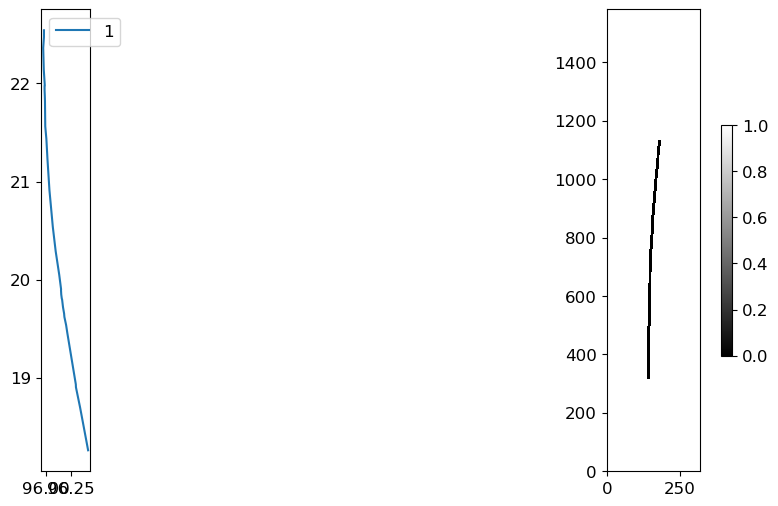

'/penguin/hucy/Mandalay/ALOS2_A152/ion/ion_cal/msk_80rlks_224alks.msk'

In [3]:
# work dir
os.chdir(os.path.join(proj_dir, dname, 'ion/ion_cal'))
print('Go to directory:', os.path.join(proj_dir, 'ion/ion_cal'))

# generate mask for EQ ruptures
mli_str = '80rlks_224alks'
rupture_width = 10
ion_lookup_file = [f'lat_{mli_str}.lat', f'lon_{mli_str}.lon']
ion_msk_file = os.path.abspath(f'msk_{mli_str}.msk')
ion_int_file = os.path.abspath(f'lower_{mli_str}.int')

# prep_isce.main(f'-f {ion_int_file} -m ../../250211.track.xml -g ./  -b ../../baselines'.split())
generate_mask4earthquake_rupture(gmt_lonlat_file, int_file=ion_int_file, msk_file=ion_msk_file, lookup_file=ion_lookup_file, rupture_width=rupture_width)

In [4]:
os.chdir(os.path.join(proj_dir, dname, 'ion/ion_cal'))
print(f'cd {os.path.join(proj_dir, dname, "ion/ion_cal")}')
print(f'screen -S {dname.split("_")[1]}_UNW -L\nsource ~/.bash_profile\nload_isce2_dev')

for suffix in ['lower', 'upper']:
    ion_int_file = f'{suffix}_{mli_str}.int'
    ion_cor_file = f'{suffix}_{mli_str}.phsig'
    ion_unw_file = f'{suffix}_{mli_str}.unw'
    # prepare metadata
    # prep_isce.main(f'-f {os.path.abspath(ion_int_file)} -m ../../2*.track.xml -g ./'.split())
    # unwrap cmd
    cmd = f'unwrap.py -i {ion_int_file} -c {ion_cor_file} -o {ion_unw_file} --mask {ion_msk_file} '
    cmd += '--max-comp 20  --init-only --init-method MCF --cost-mode DEFO '
    print(cmd)
    os.system(cmd)

# re-run alos2App
print('\n'+'-'*50)
os.chdir(os.path.join(proj_dir, dname))
print(f'cd {os.path.join(proj_dir, dname)}')
cmd = 'alos2App.py alos2App.xml --steps --start=ion_filt --end=filt'
print(cmd)
os.system(cmd)

cd /penguin/hucy/Mandalay/ALOS2_A152/ion/ion_cal
screen -S A152_UNW -L
source ~/.bash_profile
load_isce2_dev
unwrap.py -i lower_80rlks_224alks.int -c lower_80rlks_224alks.phsig -o lower_80rlks_224alks.unw --mask /penguin/hucy/Mandalay/ALOS2_A152/ion/ion_cal/msk_80rlks_224alks.msk --max-comp 20  --init-only --init-method MCF --cost-mode DEFO 
masking out pixels using file: /penguin/hucy/Mandalay/ALOS2_A152/ion/ion_cal/msk_80rlks_224alks.msk (8191 pixels)
write masked interferograms to file: lower_80rlks_224alks_msk.int
write file: lower_80rlks_224alks_msk.int
write file: lower_80rlks_224alks_msk.int.rsc
Using default ISCE Path: /home/hucy/tools/miniforge/envs/earthscope/lib/python3.11/site-packages/isce
write file: lower_80rlks_224alks_msk.int.xml
write file: lower_80rlks_224alks_msk.int.vrt
phase unwrapping with SNAPHU ...
SNAPHU cost mode: DEFO
SNAPHU init only: True
SNAPHU init method: MCF
SNAPHU max number of connected components: 20

snaphu v1.4.2
Reading wrapped phase from file lo

sh: 1: alos2App.py: not found


32512

## 3. Phase unwrapping

### 3.1 Subset (no use)

In [4]:
# go to sub directory
os.chdir(os.path.join(proj_dir, dname,f'insar'))
#print('Go to directory:', proj_dir)

# prepare meta and cor file
prep_isce.main(f'-f {int_file} -m ../250123.track.xml -g ../'.split())
isce_utils.estimate_coherence(int_file, cor_file)

preparing RSC file for geometry files
preparing RSC file for: filt_250211-250408_5rlks_28alks.int
Done.
Using default ISCE Path: /home/hucy/tools/miniforge/envs/earthscope/lib/python3.11/site-packages/isce
GDAL open (R): filt_250211-250408_5rlks_28alks.int.vrt
API open (WR): filt_250211-250408_5rlks_28alks.cor

 << PS filtering >>


 interferogram width:  5111  number of lines/patch:  3700
 start line:        1  number of lines:   12660
 start sample:      1  end sample:         5111
 wisdomFile, length =            0

 azimuth buffer size:                             3700
 overlap between azimuth patches:                  200
 total overlap between azimuth patches:            264
 offset in overlap region for phase  bootstrap:    132
 lines to increment for the next patch:           3436
 number of patches:                                  4

 PATCH:   1   starting line:     0    lines read: 3700
 starting output line:    1   ending output line: 3568

 PATCH:   2   starting line:  343

### 3.2 Generate mask for EQ ruptures

+ exclude fault rupture traces
+ [skip] exclude water body. Skipped as water body is not large & not in the near field -> not a problem for PU.
+ [skip] exclude very low coherent pixels. Skipped to let SNAPHU handle it.

Go to directory: /penguin/hucy/Mandalay/ALOS2_A152/insar
translating lat/lon into local X/Y coordiantes...
[==================================================] fault 36/36 (2 points)  197s /     6s 
[[(2876, 9061)], [(2854, 8956)], [(2809, 8792)], [(2750, 8457)], [(2734, 8345)], [(2716, 8210)], [(2712, 8207)], [(2698, 8136)], [(2685, 8054)], [(2671, 7972)], [(2648, 7849)], [(2597, 7586)], [(2588, 7510)], [(2576, 7393)], [(2528, 7066)], [(2500, 6863)], [(2464, 6595)], [(2439, 6359)], [(2403, 6027)], [(2372, 5646)], [(2354, 5278)], [(2340, 5052)], [(2336, 5040)], [(2328, 4970)], [(2324, 4907)], [(2326, 4891)], [(2317, 4775)], [(2315, 4671)], [(2309, 4620)], [(2310, 4490)], [(2305, 4365)], [(2281, 3558)], [(2274, 3514)], [(2274, 3191)], [(2269, 2655)], [(2268, 2518)]]
rasterize local X/Y coordiantes with a width of 20 pixels
write file: 250211-250408_5rlks_28alks.msk
write file: 250211-250408_5rlks_28alks.msk.rsc
write mask to file: 250211-250408_5rlks_28alks.msk
ASCENDING orbit -> flip u

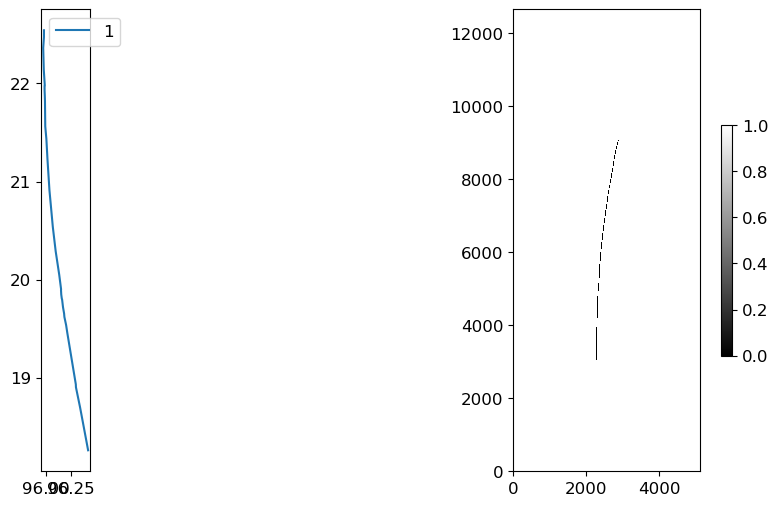

'250211-250408_5rlks_28alks.msk'

In [5]:
os.chdir(os.path.join(proj_dir, dname,f'insar'))
gmt_lonlat_file = os.path.join('/penguin/eedy/25EQ_myanmar/simple_rupture_trace.lonlat')
generate_mask4earthquake_rupture(gmt_lonlat_file, int_file=int_file, msk_file=msk_file, lookup_file=[lat_file, lon_file])

### 3.3 Re-run phase unwrapping

In [6]:
print(f'cd {work_dir}')
print(f'screen -S {dname.split("_")[1]}_UNW -L\nload_isce2_dev')
cmd = f'unwrap.py -i {int_file} -c {cor_file} -o {unw_file} --mask {msk_file} '
cmd += '--max-comp 20 --max-defo 10 --init-only --init-method MCF --cost-mode DEFO '
print(cmd)

cd /penguin/hucy/Mandalay/
screen -S A152_UNW -L
load_isce2_dev
unwrap.py -i filt_250211-250408_5rlks_28alks.int -c filt_250211-250408_5rlks_28alks.cor -o filt_250211-250408_5rlks_28alks.unw --mask 250211-250408_5rlks_28alks.msk --max-comp 20 --max-defo 10 --init-only --init-method MCF --cost-mode DEFO 


## 4. Mask and geocode

Copy files from `insar/sub` on cluster to `insar` on laptop.

In [21]:
work_dir = os.path.join(proj_dir, dname, 'insar')
os.chdir(work_dir)
print('Go to directory:', work_dir)

# mask
mask.main(f'{unw_file}.conncomp -m {wbd_file} --mask-vmax 1 --fill 0'.split())
mask.main(f'{unw_file} -m {unw_file}_msk.conncomp'.split())
mask.main(f'{fbase}.ion -m {wbd_file} --mask-vmax 1'.split())

# geocode
S, N, W, E = 16.5, 24, 94, 98  
step = 0.00277778               
!mkdir -p geo

opt = f'--lat-file {lat_file} --lon-file {lon_file} --fill nan --bbox {S} {N} {W} {E} --lalo-step -{step} {step}'
geocode.main(f'filt_{fbase}_msk.unw -o ./geo/geo_filt_msk.unw {opt}'.split())
geocode.main(f'filt_{fbase}.cor -o ./geo/geo_filt.cor {opt}'.split())
geocode.main(f'{fbase}.los -o ./geo/los.geo {opt}'.split())
geocode.main(f'{fbase}_msk.ion -o ./geo/ion_msk.geo {opt}'.split())

Go to directory: /penguin/hucy/Mandalay/ALOS2_A152/insar
mask out pixels with value > 1.0 in mask file
masking band1 from filt_250211-250408_5rlks_28alks.unw.conncomp ...


write file: filt_250211-250408_5rlks_28alks.unw_msk.conncomp
write file: filt_250211-250408_5rlks_28alks.unw_msk.conncomp.rsc
masking magnitude from filt_250211-250408_5rlks_28alks.unw ...
masking phase     from filt_250211-250408_5rlks_28alks.unw ...
write file: filt_250211-250408_5rlks_28alks_msk.unw
write file: filt_250211-250408_5rlks_28alks_msk.unw.rsc
mask out pixels with value > 1.0 in mask file
masking phase from 250211-250408_5rlks_28alks.ion ...
write file: 250211-250408_5rlks_28alks_msk.ion
write file: 250211-250408_5rlks_28alks_msk.ion.rsc
number of processor to be used: 1
resampling software: pyresample
read latitude / longitude from lookup table file: 250211-250408_5rlks_28alks.lat
output pixel size in (lat, lon) in degree: (-0.00277778, 0.00277778)
output area extent in (S, N, W, E) in degree: (16.499994, 24.0, 94.0, 98.0000032)
output file row / column number: (2700, 1440)
[1/1] preparing geometry for dest_box: (0, 0, 1440, 2700) --> full src_box: (0, 0, 5111, 12660)
--

In [22]:
# spatial reference
!reference_point.py ./geo/geo_filt_msk.unw --lat 23  --lon 95.5
print('Done.')

ERROR 1: PROJ: proj_create_from_database: Open of /home/hucy/tools/miniforge/envs/earthscope/share/proj failed
--------------------------------------------------
input reference point in lat/lon: (23.0, 95.5)
input reference point in y/x: (360, 540)
--------------------------------------------------
skip spatial referencing for magnitude, as it's not in ['phase', 'displacement']
write file: ./geo/geo_filt_msk.unw
write file: ./geo/geo_filt_msk.unw.rsc
Done.


In [23]:
from mintpy.cli import load_data, smallbaselineApp
# write geometry HDF5 file
work_dir = os.path.join(proj_dir, dname, 'insar')
os.chdir(work_dir)
print('Go to directory:', work_dir)

config = f"""# vim: set filetype=cfg:
########## 1. Load Data (--load to exit after this step)
## load_data.py -H to check more details and example inputs.
mintpy.load.processor        = isce
##---------for ISCE only:
mintpy.load.metaFile         = {os.path.join(proj_dir, dname, f'{date1}.track.xml')}
mintpy.load.baselineDir      = None
##---------geometry datasets:
mintpy.load.demFile          = {os.path.join(work_dir, f'{fbase}.hgt')}
mintpy.load.lookupYFile      = {os.path.join(work_dir, f'{fbase}.lat')}
mintpy.load.lookupXFile      = {os.path.join(work_dir, f'{fbase}.lon')}
mintpy.load.incAngleFile     = {os.path.join(work_dir, f'{fbase}.los')}
mintpy.load.azAngleFile      = {os.path.join(work_dir, f'{fbase}.los')}
"""
S, N, W, E = 16.5, 24, 94, 98  
step = 0.00277778 
opt = f'--lat-file {lat_file} --lon-file {lon_file} --fill nan --bbox {S} {N} {W} {E} --lalo-step -{step} {step}'
sname, oname = dname.split('_')[:2]
config_file = os.path.join(work_dir, f'{sname}_{oname}.txt')
print('write MintPy configuration to file: {}'.format(config_file))
with open(config_file, "w") as fid:
    fid.write(config)
smallbaselineApp.main(f'{config_file} -g'.split())
# write geometryRadar.h5
load_data.main(f'-t smallbaselineApp.cfg --geom'.split())
# write geometryGeo.h5
geocode.main(f'./inputs/geometryRadar.h5 -o ./geo/geometryGeo.h5 {opt}'.split())

Go to directory: /penguin/hucy/Mandalay/ALOS2_A152/insar
write MintPy configuration to file: /penguin/hucy/Mandalay/ALOS2_A152/insar/ALOS2_A152.txt
--------------------------------------------------
Project name: ALOS2_A152
Go to work directory: /penguin/hucy/Mandalay/ALOS2_A152/insar
read custom template file: /penguin/hucy/Mandalay/ALOS2_A152/insar/ALOS2_A152.txt
update default template based on input custom template
No new option value found, skip updating /penguin/hucy/Mandalay/ALOS2_A152/insar/smallbaselineApp.cfg
copy ALOS2_A152.txt       to inputs   directory for backup.
copy ALOS2_A152.txt       to pic      directory for backup.
read default template file: /penguin/hucy/Mandalay/ALOS2_A152/insar/smallbaselineApp.cfg
Go back to directory: /penguin/hucy/Mandalay/ALOS2_A152/insar

################################################
   Normal end of smallbaselineApp processing!
################################################
Time used: 00 mins 1.2 secs

processor : isce
SAR platform/

/home/hucy/tools/miniforge/envs/earthscope/lib/python3.11/site-packages/mintpy/load_data.py:708: UserWarning: prep_isce.py failed. Assuming its result exists and continue...
  warnings.warn('prep_isce.py failed. Assuming its result exists and continue...')


number of processor to be used: 1
resampling software: pyresample
read latitude / longitude from lookup table file: 250211-250408_5rlks_28alks.lat
output pixel size in (lat, lon) in degree: (-0.00277778, 0.00277778)
output area extent in (S, N, W, E) in degree: (16.499994, 24.0, 94.0, 98.0000032)
output file row / column number: (2700, 1440)
[1/1] preparing geometry for dest_box: (0, 0, 1440, 2700) --> full src_box: (0, 0, 5111, 12660)
--------------------------------------------------
resampling file: ./inputs/geometryRadar.h5
--------------------------------------------------
grab dataset structure from ref_file: ./inputs/geometryRadar.h5
create HDF5 file: ./geo/geometryGeo.h5 with w mode
create dataset  : azimuthAngle       of float32                   in size of (2700, 1440)         with compression = lzf
create dataset  : height             of float32                   in size of (2700, 1440)         with compression = lzf
create dataset  : incidenceAngle     of float32           

In [24]:
meta = readfile.read_roipac_rsc(os.path.join(proj_dir, dname, 'data.rsc'))
meta['DATE12'] = f'{date1}-{date2}'
ut.add_attribute('./geo/geo_filt_msk.unw', meta)

'./geo/geo_filt_msk.unw'

In [25]:
!tropo_pyaps3.py -f ./geo/geo_filt_msk.unw -g ./geo/geometryGeo.h5

ERROR 1: PROJ: proj_create_from_database: Open of /home/hucy/tools/miniforge/envs/earthscope/share/proj failed
weather model: ERA5 - dry (hydrostatic) and wet delay
weather directory: /penguin/hucy/Mandalay/ALOS2_A152/insar
output tropospheric delay     time-series file: ./geo/ERA5.h5
output corrected displacement time-series file: ./geo/geo_filt_msk_ERA5.unw
read dates/time info from file: ./geo/geo_filt_msk.unw
time of cloest available product: 18:00 UTC

--------------------------------------------------------------------------------
Download global atmospheric model files...
update mode: ON
output file: ./geo/ERA5.h5
1) output file exists and is newer than all GRIB files.
2) output file has the same len/wid as the geometry file and contains all dates
3) output file is fully written.
run or skip: skip
Skip downloading and use existed troposhperic delay HDF5 file: ./geo/ERA5.h5.

--------------------------------------------------------------------------------
Calculate tropospheric d

In [26]:
!solid_earth_tides.py ./geo/geo_filt_msk_ERA5.unw -g ./geo/geometryGeo.h5

ERROR 1: PROJ: proj_create_from_database: Open of /home/hucy/tools/miniforge/envs/earthscope/share/proj failed
prepare LOS geometry in geo-coordinates from file: ./geo/geometryGeo.h5
read incidenceAngle from file: ./geo/geometryGeo.h5
read azimuthAngle   from file: ./geo/geometryGeo.h5
get the unit vector for enu2los projection with mean value: E = -0.607, N = -0.113, U = 0.778.

--------------------------------------------------
calculating solid Earth tides using PySolid (Milbert, 2018; Yunjun et al., 2022) ...
 Mild Warning -- time crossed leap second table
   boundaries.  Boundary edge value used instead
[======================= 50%                       ] 2025-02-11T17:41:29 (1/2)    0s /     0s Mild Warning -- time crossed leap second table
   boundaries.  Boundary edge value used instead
[==================================================] 2025-04-08T17:41:29 (2/2) 
delete exsited file: ./geo/SET.h5
create HDF5 file: ./geo/SET.h5 with w mode
create dataset /timeseries of float32

/penguin/hucy/Mandalay/ALOS2_A152/insar
run view.py in MintPy version 1.6.2, date 2025-07-07
input file is isce .unw file: /penguin/hucy/Mandalay/ALOS2_A152/insar/geo/geo_filt_msk_ERA5_SET.unw in float32 format
file size in y/x: (2700, 1440)
input dataset: "['phase']"
num of datasets in file geo_filt_msk_ERA5_SET.unw: 2
datasets to exclude (0):
[]
datasets to display (1):
['phase']
data   coverage in y/x: (0, 0, 1440, 2700)
subset coverage in y/x: (0, 0, 1440, 2700)
data   coverage in lat/lon: (94.0, 24.0, 98.0000032, 16.499994)
subset coverage in lat/lon: (94.0, 24.0, 98.0000032, 16.499994)
------------------------------------------------------------------------
area exceed 2000 pixels, turn off default DEM contour display
colormap: RdBu
initiate cartopy map projection: PlateCarree
figure title: ALOS2_A152_20250211_20250408_IFG
figure size : [4.3, 8.0]
Apply math operation: reverse
data    range: [-0.680685, 0.743657] m
display range: [-0.5, 0.5] m
reading DEM: elevation_mli.dem ...
d

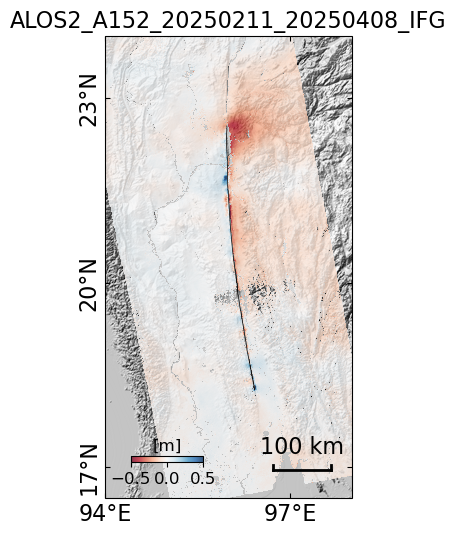

In [46]:
#unw_file = os.path.join(proj_dir, 'data_v2', dname, 'geo_filt_msk_ERA5_SET.unw')
os.chdir(os.path.join(proj_dir, dname,f'insar'))
!pwd
unw_file = 'geo/geo_filt_msk_ERA5_SET.unw'
out_file = f'geo/{dname}_20{date1}_20{date2}_IFG.png'
cmd = f'view.py {unw_file} phase --dem {dem_file} --dem-nocontour --shade-exag 0.05 --faultline {flt_file} '
cmd += f'-c RdBu -u m -v -0.5 0.5 --lalo-label --lalo-step 3 --ylabel-rot 90 --cbar-nbins 5 '
cmd += f'--scalebar 0.3 0.80 0.06 --title {dname}_20{date1}_20{date2}_IFG --ref-size 4 --math reverse --dpi 600 '
cmd += f' --nocbar --noreference'
from cartopy import crs as ccrs
data, atr, inps = prep_slice(cmd)

fig, ax = plt.subplots(figsize=[6, 6], subplot_kw=dict(projection=ccrs.PlateCarree()))
ax, inps, im, cbar = plot_slice(ax, data, atr, inps)
# axis format

cax = fig.add_axes([0.35, 0.17, 0.12, 0.01])
cbar = fig.colorbar(im, cax=cax, orientation='horizontal', ticks=[-0.5, 0, 0.5])
cbar.ax.xaxis.set_label_position('top')
cbar.ax.set_xlabel(f'[m]', fontsize=12)

print('save figure to file', out_file)
plt.savefig(out_file, bbox_inches='tight', transparent=True, dpi=600)


view.py ./geo/ion_msk.geo band1 --title ionosphere --dem /penguin/eedy/25EQ_myanmar/DEM/elevation_mli.dem -c cmy -u radian --wrap --lalo-label --lalo-step 3 --ylabel-rot 90 --noreference --noverbose --save --dem-nocontour --shade-exag 0.05 --save
initiate cartopy map projection: PlateCarree
Un-scalable display unit: radian


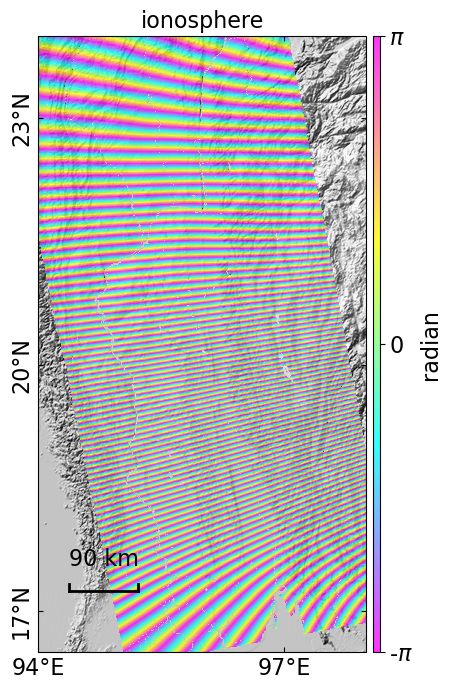

view.py ./geo/ERA5.h5 250408 --ref-date 250211 --title troposphere --dem /penguin/eedy/25EQ_myanmar/DEM/elevation_mli.dem -c cmy -u radian --wrap --lalo-label --lalo-step 3 --ylabel-rot 90 --noreference --noverbose --save --dem-nocontour --shade-exag 0.05 --save
initiate cartopy map projection: PlateCarree


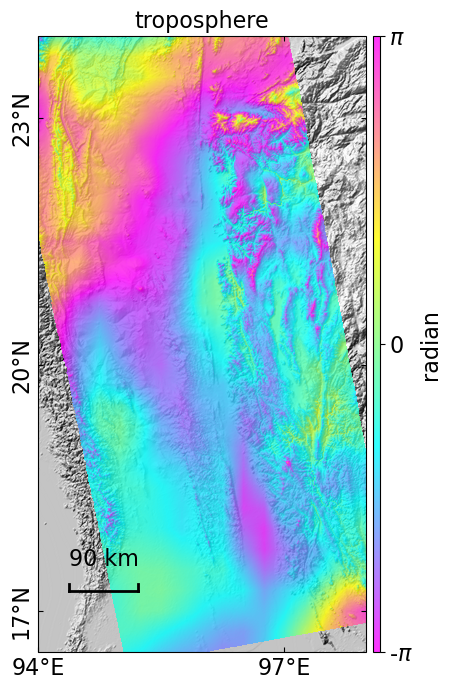

view.py ./geo/SET.h5 250408 --ref-date 250211 --dem /penguin/eedy/25EQ_myanmar/DEM/elevation_mli.dem -c cmy -u radian --wrap --lalo-label --lalo-step 3 --ylabel-rot 90 --noreference --noverbose --save --dem-nocontour --shade-exag 0.05 --save --title solid Earth tides
initiate cartopy map projection: PlateCarree


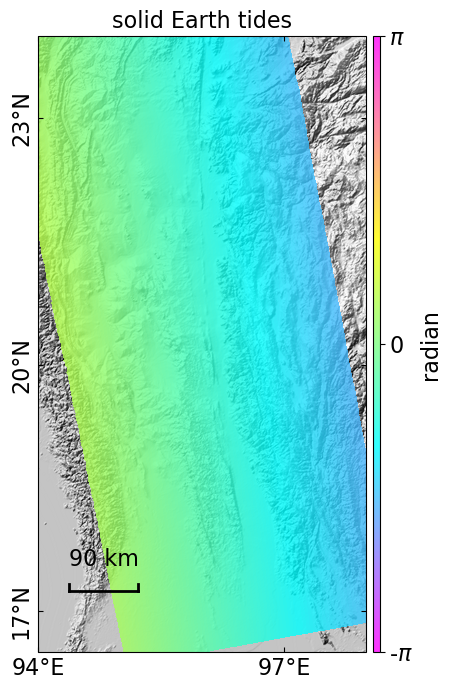

view.py ./geo/geo_filt_ori.int phase --wrap --dem /penguin/eedy/25EQ_myanmar/DEM/elevation_mli.dem -c cmy -u radian --wrap --lalo-label --lalo-step 3 --ylabel-rot 90 --noreference --noverbose --save --dem-nocontour --shade-exag 0.05 --save --title wrapped phase
initiate cartopy map projection: PlateCarree


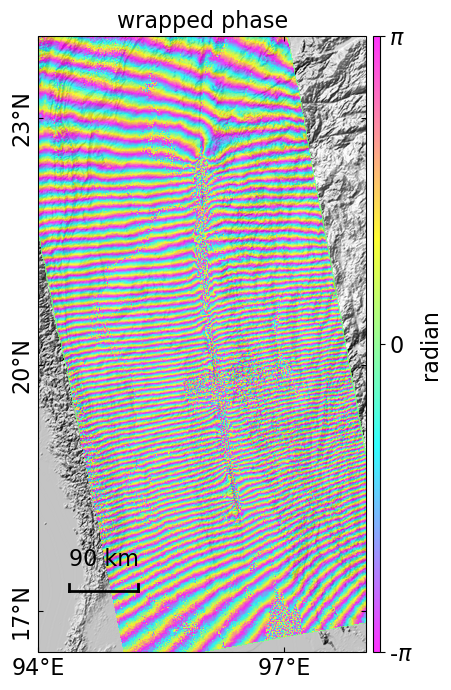

In [22]:
opt = f'--dem {dem_file} -c cmy -u radian --wrap --lalo-label --lalo-step 3 --ylabel-rot 90 --noreference --noverbose --save --dem-nocontour --shade-exag 0.05'
view.main(f'./geo/ion_msk.geo band1 --title ionosphere {opt} --save'.split())
view.main(f'./geo/ERA5.h5 {date2} --ref-date {date1} --title troposphere {opt} --save'.split())
view.main(f'./geo/SET.h5 {date2} --ref-date {date1} {opt} --save '.split() +  ['--title', 'solid Earth tides'])
view.main(f'./geo/geo_filt_ori.int phase --wrap {opt} --save'.split() + ['--title', 'wrapped phase'])

view.py ./geo/geo_filt_msk_ERA5_SET.unw phase -u m -v -0.5 0.5 --math reverse --dem /penguin/eedy/25EQ_myanmar/DEM/elevation_mli.dem -c RdBu --lalo-label --lalo-step 3 --ylabel-rot 90 --noreference --noverbose --save --dem-nocontour --shade-exag 0.05 --title ALOS2_A152_20250211_20250408_IFG
initiate cartopy map projection: PlateCarree


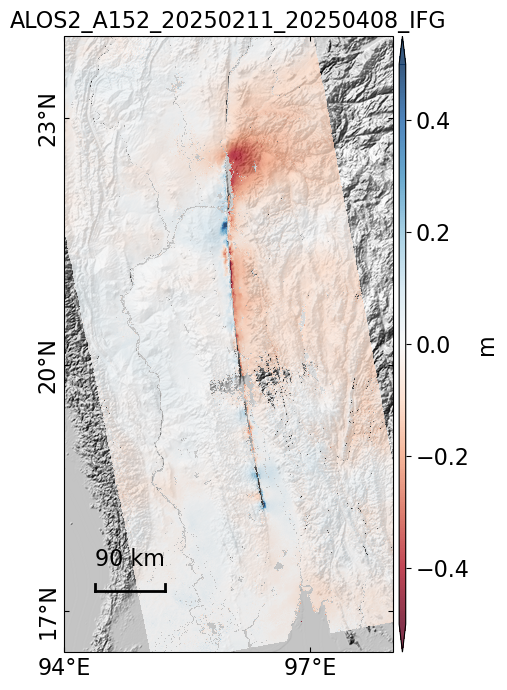

In [48]:
view.main(f'./geo/geo_filt_msk_ERA5_SET.unw phase -u m -v -0.5 0.5 --math reverse --dem {dem_file} -c RdBu --lalo-label --lalo-step 3 --ylabel-rot 90 --noreference --noverbose --save --dem-nocontour --shade-exag 0.05'.split() + ['--title', 'ALOS2_A152_20250211_20250408_IFG'])

In [32]:
!ls ./geo

ALOS2_A152_20250211_20250408_IFG.png  geo_filt_msk_ERA5.unw.vrt
enu.geo				      geo_filt_msk_ERA5.unw.xml
enu.geo.rsc			      geo_filt_msk.unw
enu.geo.vrt			      geo_filt_msk.unw.rsc
enu.geo.xml			      geo_filt_msk.unw.vrt
ERA5.h5				      geo_filt_msk.unw.xml
geo_amp.amp			      geo_filt_ori.int
geo_amp.amp.rsc			      geo_filt_ori.int.rsc
geo_amp.amp.vrt			      geo_filt_ori.int.vrt
geo_amp.amp.xml			      geo_filt_ori.int.xml
geo_filt.cor			      geometryGeo.h5
geo_filt.cor.rsc		      ion_msk.geo
geo_filt.cor.vrt		      ion_msk.geo.rsc
geo_filt.cor.xml		      ion_msk.geo.vrt
geo_filt_msk_ERA5_SET.unw	      ion_msk.geo.xml
geo_filt_msk_ERA5_SET.unw.rsc	      los.geo
geo_filt_msk_ERA5_SET.unw.vrt	      los.geo.rsc
geo_filt_msk_ERA5_SET.unw.xml	      los.geo.vrt
geo_filt_msk_ERA5.unw		      los.geo.xml
geo_filt_msk_ERA5.unw.rsc	      SET.h5


view.py ./geo/geo_filt_msk_ERA5_SET.unw phase --wrap --dem /penguin/eedy/25EQ_myanmar/DEM/elevation_mli.dem -c cmy -u radian --wrap --lalo-label --lalo-step 3 --ylabel-rot 90 --noreference --noverbose --save --dem-nocontour --shade-exag 0.05 --title wrapped phase


initiate cartopy map projection: PlateCarree


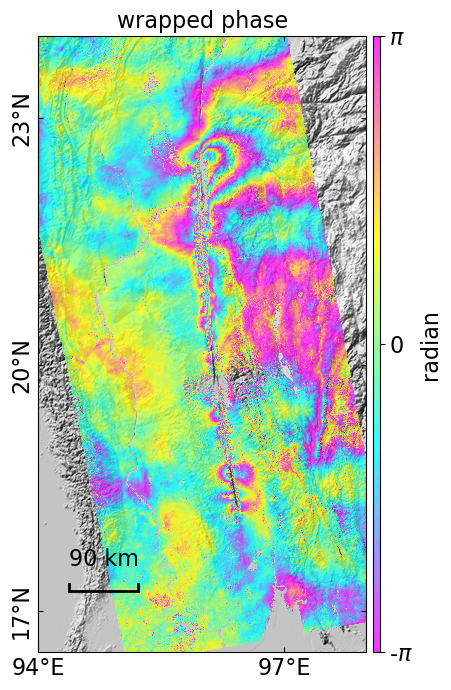

In [29]:
view.main(f'./geo/geo_filt_msk_ERA5_SET.unw phase --wrap {opt} '.split() + ['--title', 'wrapped phase'])


view.py ./geo/geo_filt_msk.unw phase --wrap --dem /penguin/eedy/25EQ_myanmar/DEM/elevation_mli.dem -c cmy -u radian --wrap --lalo-label --lalo-step 3 --ylabel-rot 90 --noreference --noverbose --save --dem-nocontour --shade-exag 0.05 --title wrapped phase
initiate cartopy map projection: PlateCarree


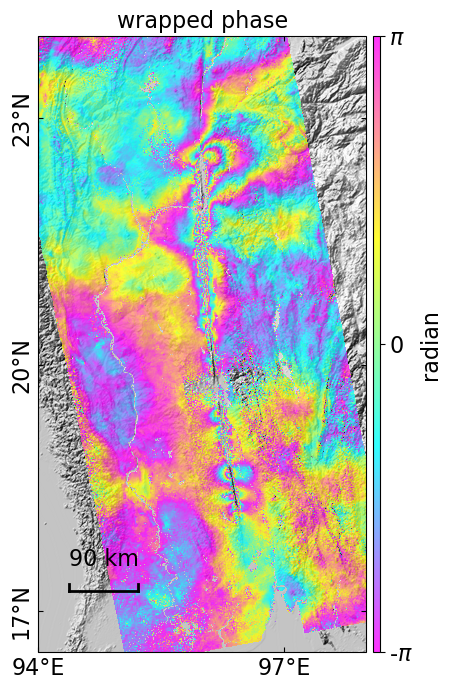

In [32]:
view.main(f'./geo/geo_filt_msk.unw phase --wrap {opt} '.split() + ['--title', 'wrapped phase'])


In [ ]:
view.main(f'./geo/geo_filt_msk.unw phase --wrap {opt} '.split() + ['--title', 'wrapped phase'])


In [13]:
work_dir = os.path.join(proj_dir, dname, 'insar')
os.chdir(work_dir)
print('Go to directory:', work_dir)
!ls ./geo/

Go to directory: /penguin/hucy/Mandalay/ALOS2_A152/insar
ALOS2_A152_20250211_20250408_IFG.png  geo_filt_msk_ERA5.unw.vrt
enu.geo				      geo_filt_msk_ERA5.unw.xml
enu.geo.rsc			      geo_filt_msk.unw
enu.geo.vrt			      geo_filt_msk.unw.rsc
enu.geo.xml			      geo_filt_msk.unw.vrt
ERA5.h5				      geo_filt_msk.unw.xml
geo_filt.cor			      geometryGeo.h5
geo_filt.cor.rsc		      ion_msk.geo
geo_filt.cor.vrt		      ion_msk.geo.rsc
geo_filt.cor.xml		      ion_msk.geo.vrt
geo_filt_msk_ERA5_SET.unw	      ion_msk.geo.xml
geo_filt_msk_ERA5_SET.unw.rsc	      los.geo
geo_filt_msk_ERA5_SET.unw.vrt	      los.geo.rsc
geo_filt_msk_ERA5_SET.unw.xml	      los.geo.vrt
geo_filt_msk_ERA5.unw		      los.geo.xml
geo_filt_msk_ERA5.unw.rsc	      SET.h5


run view.py in MintPy version 1.6.2, date 2025-07-07
input file is isce .ion file: /penguin/hucy/Mandalay/ALOS2_A152/insar/geo/ion_msk.geo in float32 format
file size in y/x: (2700, 1440)
input dataset: "['band1']"
num of datasets in file ion_msk.geo: 1
datasets to exclude (0):
[]
datasets to display (1):
['band1']
data   coverage in y/x: (0, 0, 1440, 2700)
subset coverage in y/x: (0, 0, 1440, 2700)
data   coverage in lat/lon: (94.0, 24.0, 98.0000032, 16.499994)
subset coverage in lat/lon: (94.0, 24.0, 98.0000032, 16.499994)
------------------------------------------------------------------------
area exceed 2000 pixels, turn off default DEM contour display
colormap: cmy
initiate cartopy map projection: PlateCarree
figure title: ionosphere
figure size : [4.3, 8.0]
Un-scalable display unit: radian
re-wrapping data to [-3.141592653589793, 3.141592653589793]
data    range: [-3.141588, 3.1415923] radian
display range: [-3.141592653589793, 3.141592653589793] radian
reading DEM: elevation_ml

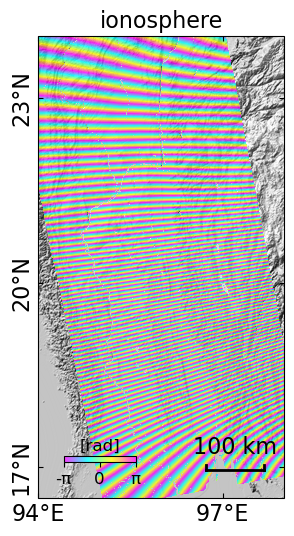

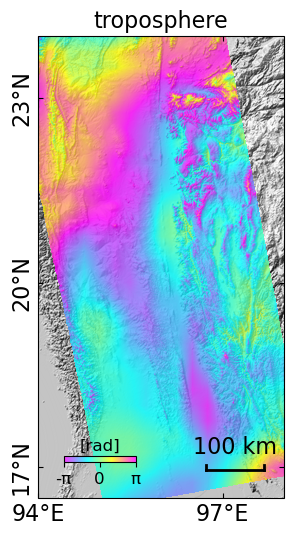

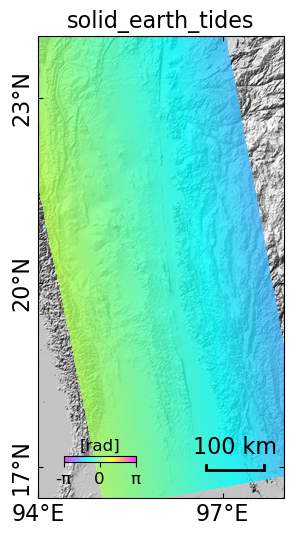

In [14]:
import numpy as np

# 修改后的代码：
# 电离层校正
ion_file = './geo/ion_msk.geo'
ion_out_file = f'./{dname}_ionosphere_20{date1}_20{date2}.png'
ion_cmd = f'view.py {ion_file} band1 --dem {dem_file} -c cmy -u radian --wrap --lalo-label --lalo-step 3 --nocbar --ylabel-rot 90 --dem-nocontour --shade-exag 0.05 --title ionosphere --dpi 600'
ion_cmd += f' --nocbar --scalebar 0.3 0.80 0.06'
ion_data, ion_atr, ion_inps = prep_slice(ion_cmd)

fig, ax = plt.subplots(figsize=[6, 6], subplot_kw=dict(projection=ccrs.PlateCarree()))
ax, ion_inps, im, cbar = plot_slice(ax, ion_data, ion_atr, ion_inps)

cax = fig.add_axes([0.35, 0.17, 0.12, 0.01])
cbar = fig.colorbar(im, cax=cax, orientation='horizontal', ticks=[-np.pi, 0, np.pi])
cbar.set_ticklabels(['-π', '0', 'π'])
cbar.ax.xaxis.set_label_position('top')
cbar.ax.set_xlabel(f'[rad]', fontsize=12)

plt.savefig(ion_out_file, bbox_inches='tight', transparent=True, dpi=600)

# 对流层校正
era5_file = './geo/ERA5.h5'
era5_out_file = f'./{dname}_troposphere_20{date1}_20{date2}.png'
era5_cmd = f'view.py {era5_file} {date2} --ref-date {date1} --dem {dem_file} -c cmy -u radian --wrap --lalo-label --lalo-step 3 --nocbar --ylabel-rot 90 --dem-nocontour --shade-exag 0.05 --title troposphere --dpi 600'
era5_cmd += f' --nocbar --scalebar 0.3 0.80 0.06'
era5_data, era5_atr, era5_inps = prep_slice(era5_cmd)

fig, ax = plt.subplots(figsize=[6, 6], subplot_kw=dict(projection=ccrs.PlateCarree()))
ax, era5_inps, im, cbar = plot_slice(ax, era5_data, era5_atr, era5_inps)

cax = fig.add_axes([0.35, 0.17, 0.12, 0.01])
cbar = fig.colorbar(im, cax=cax, orientation='horizontal', ticks=[-np.pi, 0, np.pi])
cbar.set_ticklabels(['-π', '0', 'π'])
cbar.ax.xaxis.set_label_position('top')
cbar.ax.set_xlabel(f'[rad]', fontsize=12)

plt.savefig(era5_out_file, bbox_inches='tight', transparent=True, dpi=600)

# 固体潮校正
set_file = './geo/SET.h5'
set_out_file = f'./{dname}_solid_earth_tides_20{date1}_20{date2}.png'
set_cmd = f'view.py {set_file} {date2} --ref-date {date1} --dem {dem_file} -c cmy -u radian --wrap --lalo-label --lalo-step 3 --nocbar --ylabel-rot 90 --dem-nocontour --shade-exag 0.05 --title solid_earth_tides --dpi 600'
set_cmd += f' --nocbar --scalebar 0.3 0.80 0.06 --noreference'
set_data, set_atr, set_inps = prep_slice(set_cmd)

fig, ax = plt.subplots(figsize=[6, 6], subplot_kw=dict(projection=ccrs.PlateCarree()))
ax, set_inps, im, cbar = plot_slice(ax, set_data, set_atr, set_inps)

cax = fig.add_axes([0.35, 0.17, 0.12, 0.01])
cbar = fig.colorbar(im, cax=cax, orientation='horizontal', ticks=[-np.pi, 0, np.pi])
cbar.set_ticklabels(['-π', '0', 'π'])
cbar.ax.xaxis.set_label_position('top')
cbar.ax.set_xlabel(f'[rad]', fontsize=12)

plt.savefig(set_out_file, bbox_inches='tight', transparent=True, dpi=600)

In [15]:
from mintpy.utils import isce_utils, readfile, writefile, attribute as attr

infile = 'diff_250211-250408_5rlks_28alks_ori.int'
outfile = f'filt_{infile}'
isce_utils.filter_goldstein(infile, outfile, filt_strength=0.8)

# geocode
S, N, W, E = 16.5, 24, 94, 98  
step = 0.00277778               
!mkdir -p geo

opt = f'--lat-file {lat_file} --lon-file {lon_file} --fill nan --bbox {S} {N} {W} {E} --lalo-step -{step} {step}'
geocode.main(f'{outfile} -o ./geo/geo_filt_ori.int {opt}'.split())

Using default ISCE Path: /home/hucy/tools/miniforge/envs/earthscope/lib/python3.11/site-packages/isce
Applying power-spectral filter (strength=0.8)...
GDAL open (R): diff_250211-250408_5rlks_28alks_ori.int.vrt
API open (WR): filt_diff_250211-250408_5rlks_28alks_ori.int
2025-08-06 18:31:19,676 - isce.mroipac.filter - DEBUG - width: 5111
2025-08-06 18:31:19,678 - isce.mroipac.filter - DEBUG - length: 12660
2025-08-06 18:31:19,679 - isce.mroipac.filter - DEBUG - input: diff_250211-250408_5rlks_28alks_ori.int
2025-08-06 18:31:19,680 - isce.mroipac.filter - DEBUG - output: filt_diff_250211-250408_5rlks_28alks_ori.int
2025-08-06 18:31:19,681 - isce.mroipac.filter - DEBUG - filter strength: 0.8
2025-08-06 18:31:19,682 - isce.mroipac.filter - INFO - Filtering interferogram
array width, height, offset:  5111 12660     0


line:   114


number of lines written to file: 12672
Rescaling magnitude


line: 12659

GDAL close: diff_250211-250408_5rlks_28alks_ori.int.vrt
API close:  filt_diff_250211-250408_5rlks_28alks_ori.int
number of processor to be used: 1
resampling software: pyresample
read latitude / longitude from lookup table file: 250211-250408_5rlks_28alks.lat
output pixel size in (lat, lon) in degree: (-0.00277778, 0.00277778)
output area extent in (S, N, W, E) in degree: (16.499994, 24.0, 94.0, 98.0000032)
output file row / column number: (2700, 1440)
split along y dimension (2700) into 2 boxes
    with each box up to 1350 in y dimension
[1/2] preparing geometry for dest_box: [0, 0, 1440, 1350] --> reduced src_box: (0, 5129, 5110, 11814)
[2/2] preparing geometry for dest_box: [0, 1350, 1440, 2700] --> reduced src_box: (0, 0, 5110, 6116)
--------------------------------------------------
resampling file: filt_diff_250211-250408_5rlks_28alks_ori.int
--------------------------------------------------1/2
reading complex in block (0, 5129, 5110, 11814) from filt_diff_250211-250408_5rlks_28

run view.py in MintPy version 1.6.2, date 2025-07-07
input file is isce .int file: /penguin/hucy/Mandalay/ALOS2_A152/insar/geo/geo_filt_ori.int in complex64 format
file size in y/x: (2700, 1440)
input dataset: "['phase']"
num of datasets in file geo_filt_ori.int: 2
datasets to exclude (0):
[]
datasets to display (1):
['phase']
data   coverage in y/x: (0, 0, 1440, 2700)
subset coverage in y/x: (0, 0, 1440, 2700)
data   coverage in lat/lon: (94.0, 24.0, 98.0000032, 16.499994)
subset coverage in lat/lon: (94.0, 24.0, 98.0000032, 16.499994)
------------------------------------------------------------------------
area exceed 2000 pixels, turn off default DEM contour display
colormap: cmy
initiate cartopy map projection: PlateCarree
figure title: wrapped_phase
figure size : [4.3, 8.0]
re-wrapping data to [-3.141592653589793, 3.141592653589793]
data    range: [-3.1415923, 3.1415918] radian
display range: [-3.141592653589793, 3.141592653589793] radian
reading DEM: elevation_mli.dem ...
display

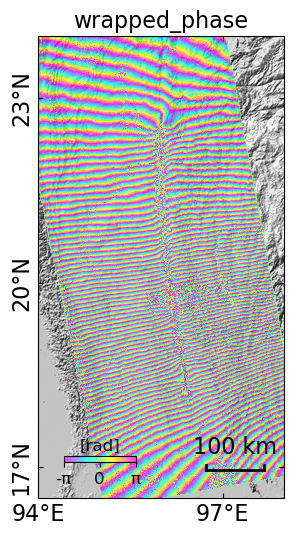

In [16]:
ion_file = './geo/geo_filt_ori.int'
ion_out_file = f'./{dname}_phase_20{date1}_20{date2}.png'
ion_cmd = f'view.py {ion_file} phase --dem {dem_file} -c cmy -u radian --wrap --lalo-label --lalo-step 3 --nocbar --ylabel-rot 90 --dem-nocontour --shade-exag 0.05 --title wrapped_phase --dpi 600'
ion_cmd += f' --scalebar 0.3 0.80 0.06 --nocbar --noreference'
ion_data, ion_atr, ion_inps = prep_slice(ion_cmd)

fig, ax = plt.subplots(figsize=[6, 6], subplot_kw=dict(projection=ccrs.PlateCarree()))
ax, ion_inps, im, cbar = plot_slice(ax, ion_data, ion_atr, ion_inps)

cax = fig.add_axes([0.35, 0.17, 0.12, 0.01])
cbar = fig.colorbar(im, cax=cax, orientation='horizontal', ticks=[-np.pi, 0, np.pi])
cbar.set_ticklabels(['-π', '0', 'π'])
cbar.ax.xaxis.set_label_position('top')
cbar.ax.set_xlabel(f'[rad]', fontsize=12)

plt.savefig(ion_out_file, bbox_inches='tight', transparent=True, dpi=600)

run view.py in MintPy version 1.6.2, date 2025-07-07
input file is isce .cor file: /penguin/hucy/Mandalay/ALOS2_A152/insar/geo/geo_filt.cor in float32 format
file size in y/x: (2700, 1440)
num of datasets in file geo_filt.cor: 1
datasets to exclude (0):
[]
datasets to display (1):
['band1']
data   coverage in y/x: (0, 0, 1440, 2700)
subset coverage in y/x: (0, 0, 1440, 2700)
data   coverage in lat/lon: (94.0, 24.0, 98.0000032, 16.499994)
subset coverage in lat/lon: (94.0, 24.0, 98.0000032, 16.499994)
------------------------------------------------------------------------
colormap: gray
initiate cartopy map projection: PlateCarree
figure title: coherence
figure size : [4.3, 8.0]
data    range: [0.0, 0.999977] 1
display range: [0.0, 1.0] 1
display data in transparency: 1.0
plot in geo-coordinate
plotting data as image via matplotlib.pyplot.imshow ...
plot scale bar: [0.3, 0.8, 0.06]
plot lat/lon label in step of 3.0 and location of [1, 0, 0, 1]
rotate Y-axis tick labels by 90.0 deg


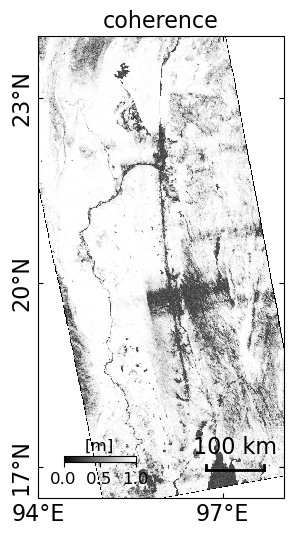

In [17]:
ion_file = './geo/geo_filt.cor'
ion_out_file = f'./{dname}_cor_20{date1}_20{date2}.png'
ion_cmd = f'view.py {ion_file} --lalo-label --lalo-step 3 --nocbar --ylabel-rot 90 --dem-nocontour --shade-exag 0.05 --title coherence --dpi 600'
ion_cmd += f' --scalebar 0.3 0.80 0.06 --nocbar --noreference'
ion_data, ion_atr, ion_inps = prep_slice(ion_cmd)

fig, ax = plt.subplots(figsize=[6, 6], subplot_kw=dict(projection=ccrs.PlateCarree()))
ax, ion_inps, im, cbar = plot_slice(ax, ion_data, ion_atr, ion_inps)

cax = fig.add_axes([0.35, 0.17, 0.12, 0.01])
cbar = fig.colorbar(im, cax=cax, orientation='horizontal', ticks=[0, 0.5, 1])
cbar.ax.xaxis.set_label_position('top')
cbar.ax.set_xlabel(f'[m]', fontsize=12)

plt.savefig(ion_out_file, bbox_inches='tight', transparent=True, dpi=600)

In [18]:
ampfile = '250211-250408_5rlks_28alks.amp'

geocode.main(f'{ampfile} -o ./geo/geo_amp.amp {opt}'.split())

number of processor to be used: 1
resampling software: pyresample
read latitude / longitude from lookup table file: 250211-250408_5rlks_28alks.lat
output pixel size in (lat, lon) in degree: (-0.00277778, 0.00277778)
output area extent in (S, N, W, E) in degree: (16.499994, 24.0, 94.0, 98.0000032)
output file row / column number: (2700, 1440)
[1/1] preparing geometry for dest_box: (0, 0, 1440, 2700) --> full src_box: (0, 0, 5111, 12660)
--------------------------------------------------
resampling file: 250211-250408_5rlks_28alks.amp
--------------------------------------------------1/1
reading band1 in block (0, 0, 5111, 12660) from 250211-250408_5rlks_28alks.amp ...
nearest resampling with pyresample.kd_tree using 1 CPU cores in 5 segments ...
--------------------------------------------------1/1
reading band2 in block (0, 0, 5111, 12660) from 250211-250408_5rlks_28alks.amp ...
nearest resampling with pyresample.kd_tree using 1 CPU cores in 5 segments ...
write file: ./geo/geo_amp.amp

run view.py in MintPy version 1.6.2, date 2025-07-07
input file is isce .amp file: /penguin/hucy/Mandalay/ALOS2_A152/insar/geo/geo_amp.amp in float32 format
file size in y/x: (2700, 1440)
input dataset: "['band1']"
num of datasets in file geo_amp.amp: 2
datasets to exclude (0):
[]
datasets to display (1):
['band1']
data   coverage in y/x: (0, 0, 1440, 2700)
subset coverage in y/x: (0, 0, 1440, 2700)
data   coverage in lat/lon: (94.0, 24.0, 98.0000032, 16.499994)
subset coverage in lat/lon: (94.0, 24.0, 98.0000032, 16.499994)
------------------------------------------------------------------------
colormap: gray
initiate cartopy map projection: PlateCarree
figure title: amplitude
figure size : [4.3, 8.0]
data    range: [-20.0, 103.32668] dB
display range: [60.0, 85.0] dB
display data in transparency: 1.0
plot in geo-coordinate
plotting data as image via matplotlib.pyplot.imshow ...
plot scale bar: [0.3, 0.8, 0.06]
plot lat/lon label in step of 3.0 and location of [1, 0, 0, 1]
rotate Y-a

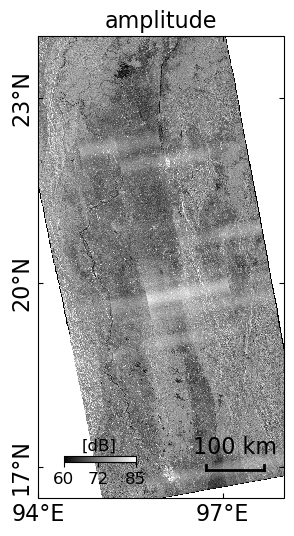

In [19]:
ion_file = './geo/geo_amp.amp'
ion_out_file = f'./{dname}_amp_20{date1}_20{date2}.png'
ion_cmd = f'view.py {ion_file} band1 -v 60 85 --lalo-label --lalo-step 3 --nocbar --ylabel-rot 90 --dem-nocontour --shade-exag 0.05 --title amplitude --dpi 600'
ion_cmd += f' --scalebar 0.3 0.80 0.06 --nocbar --noreference'
ion_data, ion_atr, ion_inps = prep_slice(ion_cmd)

fig, ax = plt.subplots(figsize=[6, 6], subplot_kw=dict(projection=ccrs.PlateCarree()))
ax, ion_inps, im, cbar = plot_slice(ax, ion_data, ion_atr, ion_inps)

cax = fig.add_axes([0.35, 0.17, 0.12, 0.01])
cbar = fig.colorbar(im, cax=cax, orientation='horizontal', ticks=[60, 72, 85])
cbar.ax.xaxis.set_label_position('top')
cbar.ax.set_xlabel(f'[dB]', fontsize=12)

plt.savefig(ion_out_file, bbox_inches='tight', transparent=True, dpi=600)


run view.py in MintPy version 1.6.2, date 2025-07-07
input file is isce .unw file: /penguin/hucy/Mandalay/ALOS2_A152/insar/geo/geo_filt_msk_ERA5_SET.unw in float32 format
file size in y/x: (2700, 1440)
input dataset: "['phase']"
num of datasets in file geo_filt_msk_ERA5_SET.unw: 2
datasets to exclude (0):
[]
datasets to display (1):
['phase']
data   coverage in y/x: (0, 0, 1440, 2700)
subset coverage in y/x: (0, 0, 1440, 2700)
data   coverage in lat/lon: (94.0, 24.0, 98.0000032, 16.499994)
subset coverage in lat/lon: (94.0, 24.0, 98.0000032, 16.499994)
------------------------------------------------------------------------
area exceed 2000 pixels, turn off default DEM contour display
colormap: cmy
initiate cartopy map projection: PlateCarree
figure title: deformation(wrapped)
figure size : [4.3, 8.0]
re-wrapping data to [-3.141592653589793, 3.141592653589793]
data    range: [-3.1415925, 3.1415894] radian
display range: [-3.141592653589793, 3.141592653589793] radian
reading DEM: elevat

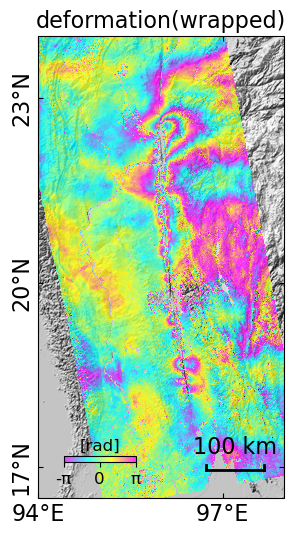

In [21]:
ion_file = './geo/geo_filt_msk_ERA5_SET.unw'
ion_out_file = f'./{dname}_phase_wrapped_20{date1}_20{date2}.png'
ion_cmd = f'view.py {ion_file} phase --dem {dem_file} -c cmy -u radian --wrap --lalo-label --lalo-step 3 --nocbar --ylabel-rot 90 --dem-nocontour --shade-exag 0.05 --title deformation(wrapped) --dpi 600'
ion_cmd += f' --scalebar 0.3 0.80 0.06 --nocbar --noreference'
ion_data, ion_atr, ion_inps = prep_slice(ion_cmd)

fig, ax = plt.subplots(figsize=[6, 6], subplot_kw=dict(projection=ccrs.PlateCarree()))
ax, ion_inps, im, cbar = plot_slice(ax, ion_data, ion_atr, ion_inps)

cax = fig.add_axes([0.35, 0.17, 0.12, 0.01])
cbar = fig.colorbar(im, cax=cax, orientation='horizontal', ticks=[-np.pi, 0, np.pi])
cbar.set_ticklabels(['-π', '0', 'π'])
cbar.ax.xaxis.set_label_position('top')
cbar.ax.set_xlabel(f'[rad]', fontsize=12)

plt.savefig(ion_out_file, bbox_inches='tight', transparent=True, dpi=600)